In [1]:
'''
1.Comprensión y preparación del dataset
¿Cuál es la estructura del dataset?
Número de filas y columnas
Tipos de datos
¿Qué problemas de calidad de datos identificaron?
Valores nulos
Duplicados
Outliers
¿Qué estrategia utilizaron para:
Reemplazar valores?
Eliminar columnas?
Transformar variables?
¿Qué variables decidieron convertir a numéricas y por qué?
¿Qué decisiones tomaron que podrían afectar el modelo?

2. Análisis exploratorio (EDA)
¿Qué variables son más relevantes descriptivamente?
¿Existen distribuciones no normales? ¿Cómo lo verificaron?
¿Detectaron correlaciones importantes?
¿Hay estacionalidad o patrones temporales?
¿Qué insights de negocio pueden extraer?*/'''

'\n1.Comprensión y preparación del dataset\n¿Cuál es la estructura del dataset?\nNúmero de filas y columnas\nTipos de datos\n¿Qué problemas de calidad de datos identificaron?\nValores nulos\nDuplicados\nOutliers\n¿Qué estrategia utilizaron para:\nReemplazar valores?\nEliminar columnas?\nTransformar variables?\n¿Qué variables decidieron convertir a numéricas y por qué?\n¿Qué decisiones tomaron que podrían afectar el modelo?\n\n2. Análisis exploratorio (EDA)\n¿Qué variables son más relevantes descriptivamente?\n¿Existen distribuciones no normales? ¿Cómo lo verificaron?\n¿Detectaron correlaciones importantes?\n¿Hay estacionalidad o patrones temporales?\n¿Qué insights de negocio pueden extraer?*/'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#estructura del dataset
df = pd.read_csv("Largest-Companies.csv", encoding="latin1")

df.head()

,Rank,Name,Sales,Profit,Assets,Market Value,Industry,Founded,Headquarters,Country,CEO,Employees
0,1,JPMorgan Chase,252.9,50.0,4090.7,588.1,Banking and Financial Services,2000.0,New York- New York,United States,Jamie Dimon,186751.0
1,2,Berkshire Hathaway,369.0,73.4,1070.0,899.1,Conglomerate,1839.0,Omaha- Nebraska,United States,Warren Edward Buffett,396500.0
2,3,Saudi Arabian Oil Company (Saudi Aramco),489.1,116.9,661.5,1919.3,Construction- Chemicals- Raw Materials,1933.0,Dhahran,Saudi Arabia,Amin bin Hasan Al-Nasser,70000.0
3,4,ICBC,223.8,50.4,6586.0,215.2,Banking and Financial Services,1984.0,Beijing,China,Wang Jingwu,427587.0
4,5,Bank of America,183.3,25.0,3273.8,307.3,Banking and Financial Services,1904.0,Charlotte- North Carolina,United States,Brian T. Moynihan,166140.0


In [4]:
#número de filas y columnas
print(df.shape)
print(df.head())


(2001, 12)
   Rank                                      Name  Sales  Profit  Assets  \
0     1                            JPMorgan Chase  252.9    50.0  4090.7   
1     2                        Berkshire Hathaway  369.0    73.4  1070.0   
2     3  Saudi Arabian Oil Company (Saudi Aramco)  489.1   116.9   661.5   
3     4                                      ICBC  223.8    50.4  6586.0   
4     5                           Bank of America  183.3    25.0  3273.8   

   Market Value                                Industry  Founded  \
0         588.1          Banking and Financial Services   2000.0   
1         899.1                            Conglomerate   1839.0   
2        1919.3  Construction- Chemicals- Raw Materials   1933.0   
3         215.2          Banking and Financial Services   1984.0   
4         307.3          Banking and Financial Services   1904.0   

                Headquarters        Country                       CEO  \
0         New York- New York  United States       

In [5]:
#columnas
df.columns

Index(['Rank', 'Name', 'Sales', 'Profit', 'Assets', 'Market Value', 'Industry',
       'Founded', 'Headquarters', 'Country', 'CEO', 'Employees'],
      dtype='str')

In [6]:
#tipos de datos
df.dtypes

Rank              int64
Name                str
Sales           float64
Profit          float64
Assets          float64
Market Value    float64
Industry            str
Founded         float64
Headquarters        str
Country             str
CEO                 str
Employees       float64
dtype: object

In [7]:
print(df.isnull().mean().sort_values(ascending=False))

Employees       0.028986
CEO             0.015492
Headquarters    0.004998
Founded         0.001000
Industry        0.001000
Sales           0.000000
Name            0.000000
Rank            0.000000
Profit          0.000000
Market Value    0.000000
Assets          0.000000
Country         0.000000
dtype: float64


In [8]:
#¿Qué problemas de calidad de datos identificaron?
#Valores nulos
resumen = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'porcentaje': (df.isnull().mean() * 100).round(2)
})
print(resumen.sort_values('porcentaje', ascending=False))

              nulos  porcentaje
Employees        58        2.90
CEO              31        1.55
Headquarters     10        0.50
Founded           2        0.10
Industry          2        0.10
Sales             0        0.00
Name              0        0.00
Rank              0        0.00
Profit            0        0.00
Market Value      0        0.00
Assets            0        0.00
Country           0        0.00


In [9]:
#Duplicados
df.duplicated().sum()

np.int64(0)

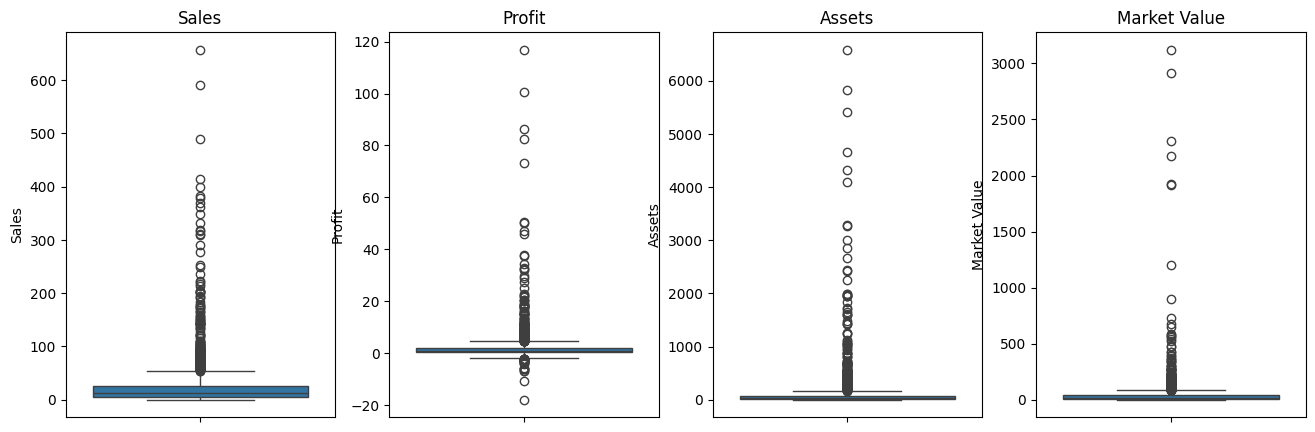

In [10]:
#Outliers
fig, axes = plt.subplots(1, 4, figsize=(16,5))
for i, col in enumerate(['Sales','Profit','Assets','Market Value']):
    sns.boxplot(data=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.show()

In [11]:
#tratamiento de valores nulos - reemplazo con 'Unknown'
Nulos_Variables = ['Employees', 'CEO', 'Headquarters', 'Founded', 'Industry']
df[Nulos_Variables] = df[Nulos_Variables].fillna('Unknown')
df[Nulos_Variables].isnull().sum()
#denifo la lista, relleno los nulos con 'Unknown' y verifico que ya no hay nulos en esas columnas

Employees       0
CEO             0
Headquarters    0
Founded         0
Industry        0
dtype: int64

In [12]:
#eeliminar columnas
df = df.drop(columns=['CEO', 'Headquarters'])

#para eliminar columnas, uso el método drop() y especifico las columnas a eliminar. Luego, asigno el resultado de nuevo a df para actualizar el DataFrame.

In [13]:
#verificar que las columnas se eliminaron
print(df.columns)

Index(['Rank', 'Name', 'Sales', 'Profit', 'Assets', 'Market Value', 'Industry',
       'Founded', 'Country', 'Employees'],
      dtype='str')


In [14]:
#transformar variables a n´umero
df['Founded'] = pd.to_numeric(df['Founded'], errors='coerce')
df['Employees'] = pd.to_numeric(df['Employees'], errors='coerce')
#funded se puede calcular la antigüedad de la empresa. Al convertirlo a numérico, puedo usarlo como una variable numérica en el análisis.
#¿Qué decisiones tomaron que podrían afectar el modelo?
#Al eliminar las columnas 'CEO' y 'Headquarters', perdemos información que podría ser relevante para el modelo. 
#Sin embargo, estas columnas tenían muchos valores nulos, decidí eliminarlas para evitar problemas de calidad de datos. 
#Esto podría afectar la capacidad del análisis para capturar ciertos patrones relacionados con la ubicación o el liderazgo de la empresa.

In [15]:
#Análisis exploratorio (EDA)
#¿Qué variables son más relevantes descriptivamente?
#Sales, Profit, Assets, Market Value, Employees

In [16]:
# Calculo la antigüedad de las empresas
df['Antiguedad'] = 2026 - df['Founded']
print(df[['Founded', 'Antiguedad']].head())

   Founded  Antiguedad
0   2000.0        26.0
1   1839.0       187.0
2   1933.0        93.0
3   1984.0        42.0
4   1904.0       122.0


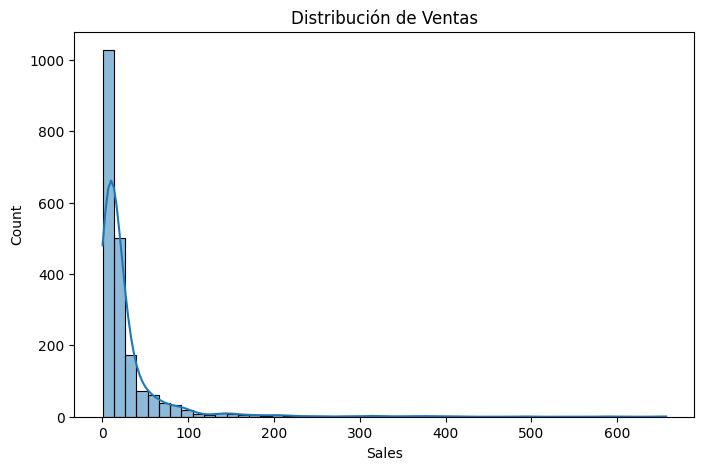

In [17]:
#¿Existen distribuciones no normales? ¿Cómo lo verificaron?
#la verifico mediante histogramas y gráficos de densidad. 
# Si la distribución es asimétrica o tiene colas largas, podría indicar que no es normal.
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title("Distribución de Ventas")
plt.show()


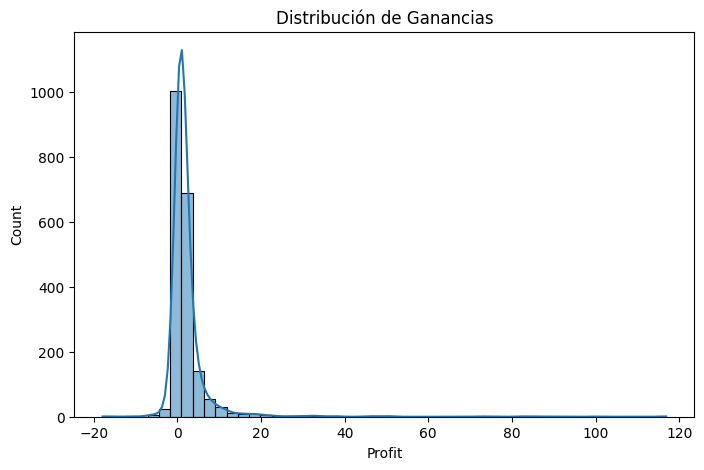

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Profit'], bins=50, kde=True)
plt.title("Distribución de Ganancias")
plt.show()

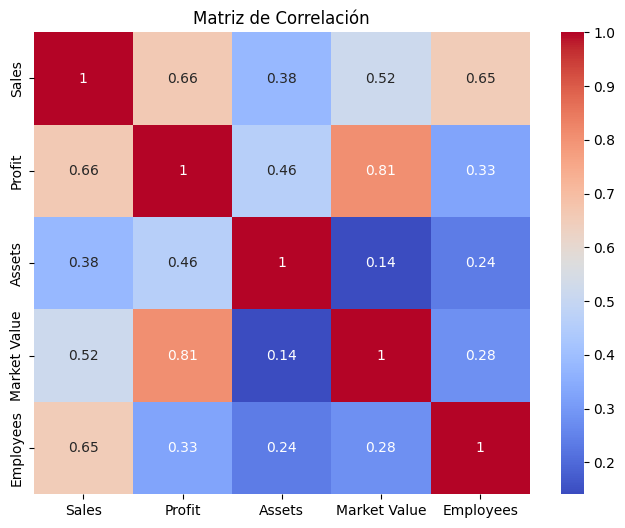

Sales     5.899353
Profit    9.968269
Assets    9.290436
dtype: float64

In [19]:
#Visualizo la relación entre variables numéricas usando un heatmap
corr = df[['Sales','Profit','Assets','Market Value','Employees']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

#distribución
df[['Sales','Profit','Assets']].skew()

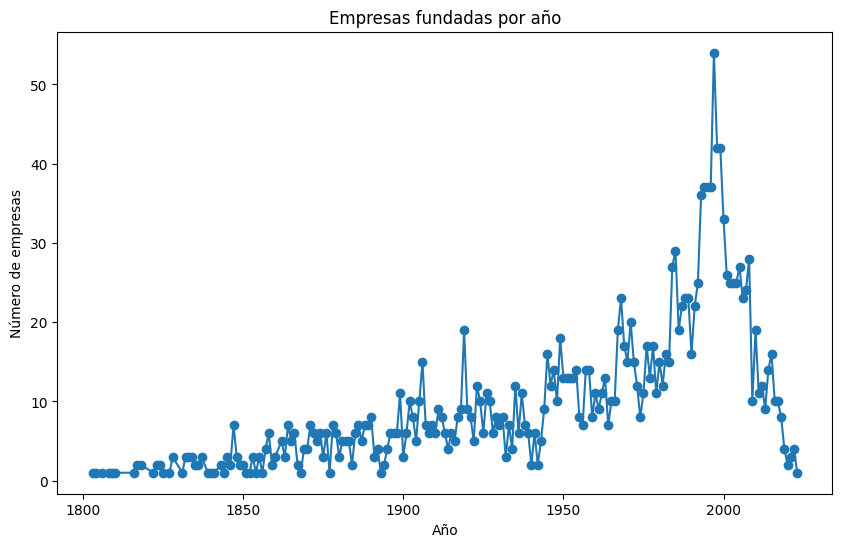

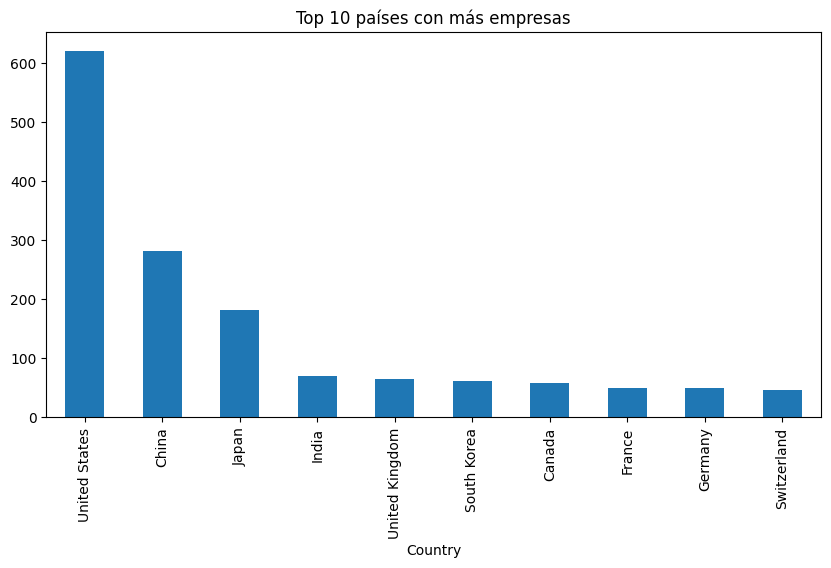

In [20]:
#empresas por año
evolucion = df[df['Founded'].between(1800, 2026)]['Founded'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.plot(evolucion.index, evolucion.values, marker='o', linestyle='-')
plt.title('Empresas fundadas por año')
plt.xlabel('Año')
plt.ylabel('Número de empresas')
plt.show()


#top empresas por pais
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title("Top 10 países con más empresas")
plt.show()

In [21]:
#¿Detectaron correlaciones importantes?
#Las empresas más rentables tienen mayor valor de mercado (Profit y Market Value tienen una correlación de 0.81).
#(sales y profit) a mayores ventas, mayores ganancias

In [22]:
#¿Hay estacionalidad o patrones temporales?
#El dataset no contiene variables temporales como años, meses y días, por lo que no existe estacionalidad.

In [23]:
#¿Qué insights de negocio pueden extraer?
# 1. Las empresas tienden a tener mayor valor de mercado de acuerdo a mayores ventas.
#Existe una fuerte concentración de empresas en países desarrollados como: Estados Unidos, China, Japón.